---
# Preview
- Dear Reviewer, с целью экономии Вашего времени пишу превью к работе. 
- Во вступительной части ноутбука излагается описание проекта и двух ключевых скриптов dataset_calorizer.py и utils_calorizer.py
- Практическая часть проекта начинается с пункта 1. EDA (см. Outline)
---

### Архитектура
В данном проекте была построена мультимодальная модель для задачи регрессии — предсказания калорийности блюда.

Модель объединяет несколько типов данных (модальностей):

1. Текстовая информация — список ингредиентов блюда.
2. Визуальная информация — изображение блюда.
3. Числовой признак — масса блюда.

Использование мультимодального подхода позволяет учитывать как визуальные характеристики блюда, так и его состав, что повышает качество предсказаний.

### Состав моделей
Архитектура модели состоит из трех основных блоков:

1. Text encoder
   Используется Transformer-модель для извлечения текстовых признаков из описания ингредиентов.

2. Image encoder
   Используется сверточная модель компьютерного зрения для извлечения визуальных признаков из изображения блюда.

3. Numerical encoder
   Масса блюда проходит через линейный слой и преобразуется в embedding.

После извлечения признаков все эмбеддинги объединяются (concatenation)
и подаются в регрессионную голову (regressor),
которая предсказывает итоговое значение калорийности.

### Предобученные модели
В проекте использованы предобученные модели (transfer learning):

1. Text model:
   distilbert-base-uncased

   Модель используется для получения текстовых эмбеддингов ингредиентов.
   Из выходов модели используется embedding CLS токена.

2. Image model:
   tf_efficientnet_b0

   Предобученная CNN-модель для извлечения визуальных признаков из изображений.
   Последний classification слой удалён, модель используется как feature extractor.

### Заморозка и разморозка слоев
Для ускорения обучения и снижения риска переобучения
в проекте использовалась стратегия заморозки слоев.

На текущем этапе обучения:

- все слои текстовой модели заморожены;
- все слои визуальной модели заморожены;
- обучается только регрессионная голова модели.

Таким образом используются фиксированные предобученные признаки,
а обучение происходит только на финальных слоях,
что значительно ускоряет обучение и стабилизирует процесс оптимизации.

### Обосновение подхода
Использование предобученных моделей позволяет:

- уменьшить время обучения;
- использовать знания, полученные на больших датасетах;
- повысить качество на относительно небольшом датасете.

Заморозка backbone моделей была выбрана как базовый стабильный вариант,
так как задача регрессии чувствительна к переобучению.

---
### dataset_zalorizer.py

Скрипт реализует:

- Кастомный `Dataset` для загрузки данных.
- Функцию `collate_fn` для корректной сборки батча.
- `Функции трансформации` изображений (аугментации и нормализация).

Скрипт отвечает за полный пайплайн подготовки данных для обучения модели - data loading и preprocessing.

#### Компоненты скрипта

`CalorieDataset` — это кастомный PyTorch Dataset.

Он отвечает за:
- загрузку строк из dataframe;
- получение текстового описания ингредиентов;
- загрузку изображения блюда по пути data/images/dish_id/rgb.png;
- применение трансформаций к изображению;
- подготовку дополнительных признаков (масса блюда);
- подготовку целевой переменной (калорийность).

На выходе __getitem__ возвращает словарь с данными,
которые используются далее в DataLoader.

Функция `collate_fn` используется DataLoader для формирования батча.

Она выполняет:

- объединение изображений в единый tensor;
- объединение числовых признаков;
- токенизацию текстов ингредиентов через tokenizer;
- приведение данных к формату, удобному для подачи в модель.

Результатом является батч со следующими элементами:
input_ids, attention_mask, image, mass, label.

Функция `get_transforms` задает preprocessing изображений.

Для train используется:
- изменение размера;
- обрезка изображения;
- нормализация;
- перевод в tensor.

Для validation/test применяются аналогичные трансформации без аугментаций, что обеспечивает корректную оценку качества модели.

Эта функция отвечает за подготовку изображений к входным требованиям модели EfficientNet.

---
### utils_zalorizer.py

Файл `utils_calorizer.py` содержит основную логику обучения модели.

В данном скрипте реализованы:
- архитектура мультимодальной модели,
- функции обучения и валидации,
- вычисление метрик,
- сохранение лучшей модели,
- логирование и сохранение истории обучения.

Таким образом, данный файл отвечает за весь training pipeline.

Цель данного файла — объединить несколько модальностей данных
(текст ингредиентов, изображение блюда и массу блюда)
в единую модель и реализовать полный цикл обучения.

#### Компоненты скрипта

`seed_everything()`

Функция фиксирует random seed для воспроизводимости экспериментов.

Она задает одинаковые состояния генераторов случайных чисел
для Python, NumPy и PyTorch, что позволяет получать стабильные результаты между запусками.

Класс `MultimodalModel`

MultimodalModel — это основная архитектура модели.

Она состоит из трех частей:

1. Text encoder (Transformer):
   извлекает признаки из текстового описания ингредиентов.

2. Image encoder (EfficientNet):
   извлекает визуальные признаки из изображения блюда.

3. Numerical encoder:
   преобразует массу блюда в embedding пространство.

После этого все эмбеддинги объединяются (concat)
и передаются в регрессионную голову (regressor),
которая предсказывает итоговую калорийность блюда.

Таким образом модель является мультимодальной
и использует как визуальную, так и текстовую информацию.

`validate()`

Функция validate выполняет инференс модели
на валидационной выборке без вычисления градиентов.

Основные задачи:
- получение предсказаний модели;
- вычисление метрики MAE;
- возврат итоговой метрики качества.

Используется после каждой эпохи обучения.

`train()`

Функция train реализует полный цикл обучения модели.

Она включает:

- инициализацию модели и tokenizer;
- настройку optimizer с разными learning rate;
- создание DataLoader;
- обучение по эпохам;
- mixed precision training (AMP) для ускорения на GPU;
- подсчет метрик MAE;
- сохранение лучшей модели;
- early stopping при достижении целевого MAE;
- сохранение истории метрик в файл.

После завершения функция возвращает историю обучения,
которая далее используется для визуализации графиков.

---
# 1. EDA

- Загрузка исходных датафреймов и осмотр данных

In [1]:
import pandas as pd

ingredients_path = 'data/ingredients.csv'
dish_path = 'data/dish.csv'
images_path = 'data/images'

In [32]:
df_ingr = pd.read_csv(ingredients_path)
df_ingr

,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes
...,...,...
550,551,pizza sauce
551,552,pomegranate
552,553,nut cheese
553,554,soy sausage


In [33]:
df_dish = pd.read_csv(dish_path)
df_dish

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train
...,...,...,...,...,...
3257,dish_1563295334,228.540009,96.0,ingr_0000000004;ingr_0000000008,train
3258,dish_1566329234,262.625214,457.0,ingr_0000000161;ingr_0000000189;ingr_000000000...,train
3259,dish_1562691737,485.676880,700.0,ingr_0000000543;ingr_0000000027;ingr_000000012...,train
3260,dish_1558458496,53.130001,77.0,ingr_0000000440,train


- Чаще всего встречается ингредиент id 77

In [34]:
df_dish['ingredients'].describe()

count                3262
unique               2294
top       ingr_0000000077
freq                   61
Name: ingredients, dtype: object

- Демонстрация рандомных 5ти изображений датасета

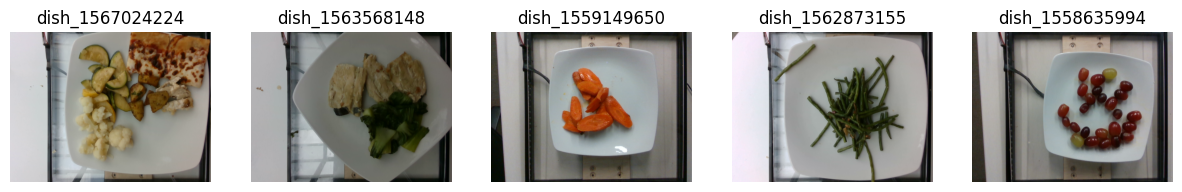

In [35]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# папка с изображениями
IMAGES_DIR = "data/images"

# случайные 5 dish_id
random_ids = random.sample(df_dish["dish_id"].tolist(), 5)

# отображаем картинки
plt.figure(figsize=(15, 5))

for i, dish_id in enumerate(random_ids, 1):

    img_path = os.path.join(
        IMAGES_DIR,
        str(dish_id),
        "rgb.png"
    )

    img = Image.open(img_path)

    plt.subplot(1, 5, i)
    plt.imshow(img)
    plt.title(str(dish_id))
    plt.axis("off")

plt.show()

- Демонстрация 5ти рандомых изображений датасета, где встречается самый частый ингредиент id 77

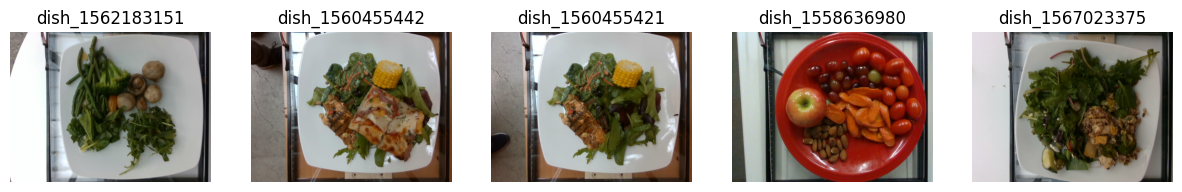

In [36]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

TARGET_INGR = "ingr_0000000077"
IMAGES_DIR = "data/images"

# --- фильтрация dish_id ---
result = df_dish.loc[
    df_dish["ingredients"].apply(lambda x: TARGET_INGR in x),
    "dish_id"
]

# --- случайные 5 dish_id ---
random_ids = random.sample(result.tolist(), 5)

# --- вывод изображений ---
plt.figure(figsize=(15, 5))

for i, dish_id in enumerate(random_ids, 1):

    img_path = os.path.join(
        IMAGES_DIR,
        str(dish_id),
        "rgb.png"
    )

    img = Image.open(img_path)

    plt.subplot(1, 5, i)
    plt.imshow(img)
    plt.title(str(dish_id))
    plt.axis("off")

plt.show()

- Наиболее встречающийся ингредиент - миндаль

In [37]:
ingredient_name = df_ingredients.loc[
    df_ingredients["id"] == 77
]
ingredient_name

,id,ingr
76,77,almonds


## 1.1. Обработка датафрейма

- В данном блоке состав ингредиентов преобразуется в читаемый вид

In [38]:
def parse_ingr(x):
    ids = x.split(";")
    return [int(i.replace("ingr_", "")) for i in ids]

df_dish["ingr_ids"] = df_dish["ingredients"].apply(parse_ingr)

- Выводим id ингредиентов отдельной фичей

In [39]:
df_dish

,dish_id,total_calories,total_mass,ingredients,split,ingr_ids
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test,"[508, 122, 26, 524, 94, 23, 189, 54, 29, 328, ..."
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train,"[312, 26, 29, 122, 508, 513, 520, 525, 161, 94..."
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test,"[448, 520, 462, 514, 152, 312, 291, 45, 122, 6..."
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train,"[471, 31, 347]"
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train,[453]
...,...,...,...,...,...,...
3257,dish_1563295334,228.540009,96.0,ingr_0000000004;ingr_0000000008,train,"[4, 8]"
3258,dish_1566329234,262.625214,457.0,ingr_0000000161;ingr_0000000189;ingr_000000000...,train,"[161, 189, 7, 525, 513, 25, 133, 511, 291, 94]"
3259,dish_1562691737,485.676880,700.0,ingr_0000000543;ingr_0000000027;ingr_000000012...,train,"[543, 27, 128, 192, 510, 437, 121, 38, 545, 50..."
3260,dish_1558458496,53.130001,77.0,ingr_0000000440,train,[440]


- Проводим мэппинг названий ингредиентов

In [40]:
ingr_map = dict(zip(df_ingr["id"], df_ingr["ingr"]))

In [41]:
ingr_map

{1: 'cottage cheese',
 2: 'strawberries',
 3: 'garden salad',
 4: 'bacon',
 5: 'potatoes',
 6: 'caesar salad',
 7: 'cauliflower',
 8: 'scrambled eggs',
 9: 'wild rice',
 10: 'steak',
 11: 'cheese pizza',
 12: 'olives',
 13: 'berries',
 14: 'asparagus',
 15: 'hash browns',
 16: 'brussels sprouts',
 17: 'pasta salad',
 18: 'turkey',
 19: 'bread',
 20: 'duck',
 21: 'squash',
 22: 'guacamole',
 23: 'brown rice',
 24: 'artic char',
 25: 'beef',
 26: 'white rice',
 27: 'broccoli',
 28: 'chicken',
 29: 'mixed greens',
 30: 'lettuce',
 31: 'cucumbers',
 32: 'tomatoes',
 33: 'bell peppers',
 34: 'celery',
 35: 'blue cheese',
 36: 'spinach (raw)',
 37: 'cantaloupe',
 38: 'pineapple',
 39: 'sausage',
 40: 'raspberries',
 41: 'blackberries',
 42: 'avocado',
 43: 'green beans',
 44: 'bean sprouts',
 45: 'carrot',
 46: 'mushroom',
 47: 'corn',
 48: 'ham',
 49: 'fish',
 50: 'tofu',
 51: 'shrimp',
 52: 'cheese',
 53: 'nuts',
 54: 'apple',
 55: 'banana',
 56: 'kiwi',
 57: 'lemon',
 58: 'orange',
 59: '

- Преобразуем ингредиенты в текст

In [42]:
def to_text(ids):
    return " ".join([ingr_map[i] for i in ids if i in ingr_map])

df_dish["ingredients_text"] = df_dish["ingr_ids"].apply(to_text)

In [43]:
df_dish

,dish_id,total_calories,total_mass,ingredients,split,ingr_ids,ingredients_text
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test,"[508, 122, 26, 524, 94, 23, 189, 54, 29, 328, ...",soy sauce garlic white rice parsley onions bro...
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train,"[312, 26, 29, 122, 508, 513, 520, 525, 161, 94...",pepper white rice mixed greens garlic soy sauc...
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test,"[448, 520, 462, 514, 152, 312, 291, 45, 122, 6...",jalapenos lemon juice pork wheat berry cabbage...
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train,"[471, 31, 347]",cherry tomatoes cucumbers baby carrots
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train,[453],deprecated
...,...,...,...,...,...,...,...
3257,dish_1563295334,228.540009,96.0,ingr_0000000004;ingr_0000000008,train,"[4, 8]",bacon scrambled eggs
3258,dish_1566329234,262.625214,457.0,ingr_0000000161;ingr_0000000189;ingr_000000000...,train,"[161, 189, 7, 525, 513, 25, 133, 511, 291, 94]",olive oil vinegar cauliflower bok choy millet ...
3259,dish_1562691737,485.676880,700.0,ingr_0000000543;ingr_0000000027;ingr_000000012...,train,"[543, 27, 128, 192, 510, 437, 121, 38, 545, 50...",chia seeds broccoli egg whites yam chicken app...
3260,dish_1558458496,53.130001,77.0,ingr_0000000440,train,[440],grapes


- Сплит на тренировочную и валидационную выборки

In [44]:
train_df = df_dish[df_dish["split"] == "train"]
val_df = df_dish[df_dish["split"] == "test"]

- Сохранение тренировочного и валидационного датафреймов

In [45]:
train_df.to_csv("data/dish_processed_train.csv", index=False)
val_df.to_csv("data/dish_processed_val.csv", index=False)

---
# 2-3. Pipeline + Train

- Релизация пайплайна обучения
- Процесс обучения модели
- Имопрт скриптов датасета и обучения модели

In [1]:
import sys
sys.path.append("./scripts")

from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from functools import partial

from dataset_calorizer import CalorieDataset, collate_fn
from dataset_calorizer import get_transforms

/Users/vladislavkravchenko/dle_yandex_sprint4/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


- Загрузка тренировочного датафрейма

In [2]:
import pandas as pd

train_df = pd.read_csv("data/dish_processed_train.csv")

- Конфигурационный файл

In [3]:
class Config:
    SEED = 42

    TEXT_MODEL_NAME = "distilbert-base-uncased"
    IMAGE_MODEL_NAME = "tf_efficientnet_b0"

    TEXT_MODEL_UNFREEZE = ""
    IMAGE_MODEL_UNFREEZE = ""

    BATCH_SIZE = 16
    TEXT_LR = 3e-5
    IMAGE_LR = 1e-4
    REGRESSOR_LR = 1e-3

    EPOCHS = 100 

    DROPOUT = 0.3
    HIDDEN_DIM = 256
    NUM_CLASSES = 1

    TRAIN_DF_PATH = "data/dish_processed_train.csv"
    VAL_DF_PATH = "data/dish_processed_val.csv"

    SAVE_PATH = "best_model.pth"

    # Таргет МАЕ
    TARGET_MAE = 50


cfg = Config()

- Формирование датасета
- Объявление токенизатора
- Формирование даталоадера
- Проверка размерности бачей
- Выбор вычислительной мощности

In [4]:
ds = CalorieDataset(
    train_df,
    transforms=get_transforms(cfg)
)

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(cfg.TEXT_MODEL_NAME)

In [6]:
from torch.utils.data import DataLoader
from functools import partial

loader = DataLoader(
    ds,
    batch_size=2,
    collate_fn=partial(collate_fn, tokenizer=tokenizer)
)

In [7]:
batch = next(iter(loader))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["image"].shape)
print(batch["mass"].shape) 
print(batch["label"].shape)

torch.Size([2, 30])
torch.Size([2, 30])
torch.Size([2, 3, 224, 224])
torch.Size([2])
torch.Size([2])


In [8]:
from utils_calorizer import MultimodalModel

model = MultimodalModel(cfg)

out = model(
    batch["input_ids"],
    batch["attention_mask"],
    batch["image"],
    batch["mass"]
)

print(out.shape)

torch.Size([2, 1])


In [9]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(device)

mps


- Обучение модели

In [10]:
from utils_calorizer import train

metrics = train(cfg, device)

training started
Epoch 0 | Loss 244.714 | Train MAE 245.15 | Val MAE 238.19
Best model saved → MAE 238.19
Epoch 1 | Loss 228.392 | Train MAE 228.37 | Val MAE 220.20
Best model saved → MAE 220.20
Epoch 2 | Loss 210.021 | Train MAE 210.16 | Val MAE 201.30
Best model saved → MAE 201.30
Epoch 3 | Loss 190.770 | Train MAE 191.19 | Val MAE 178.95
Best model saved → MAE 178.95
Epoch 4 | Loss 169.105 | Train MAE 168.50 | Val MAE 156.22
Best model saved → MAE 156.22
Epoch 5 | Loss 147.609 | Train MAE 148.11 | Val MAE 137.38
Best model saved → MAE 137.38
Epoch 6 | Loss 130.954 | Train MAE 130.34 | Val MAE 119.57
Best model saved → MAE 119.57
Epoch 7 | Loss 113.548 | Train MAE 112.66 | Val MAE 100.83
Best model saved → MAE 100.83
Epoch 8 | Loss 99.546 | Train MAE 99.80 | Val MAE 89.49
Best model saved → MAE 89.49
Epoch 9 | Loss 89.579 | Train MAE 89.63 | Val MAE 78.89
Best model saved → MAE 78.89
Epoch 10 | Loss 82.324 | Train MAE 82.39 | Val MAE 73.42
Best model saved → MAE 73.42
Epoch 11 | Loss

- Вывод метрик при достижении порога МАЕ < 50

In [11]:
print("Last epoch metrics:")
print("Train MAE:", metrics["train_mae"][-1])
print("Val MAE:", metrics["val_mae"][-1])
print("Loss:", metrics["loss"][-1])

Last epoch metrics:
Train MAE: 50.94390869140625
Val MAE: 49.53805160522461
Loss: 50.931326684235145


- Графическое отображение метрик

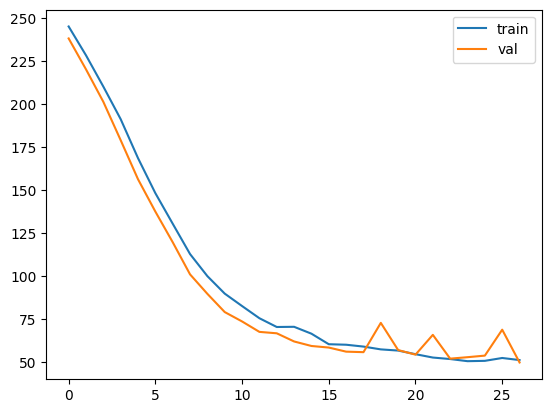

In [12]:
import matplotlib.pyplot as plt

plt.plot(metrics["train_mae"], label="train")
plt.plot(metrics["val_mae"], label="val")
plt.legend()
plt.show()

- Считывание метрик из сохраненного файла (проверка истории обучения модели)

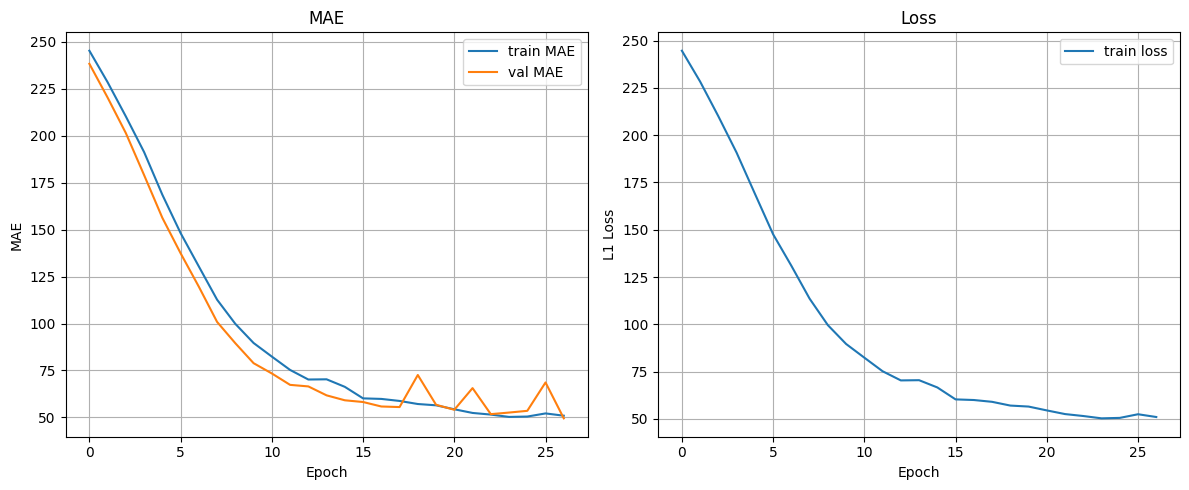

In [13]:
import json
import matplotlib.pyplot as plt

# ===== загрузка =====
with open("training_history.json", "r") as f:
    metrics = json.load(f)

plt.figure(figsize=(12,5))

# ===== MAE =====
plt.subplot(1,2,1)
plt.plot(metrics["train_mae"], label="train MAE")
plt.plot(metrics["val_mae"], label="val MAE")
plt.title("MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

# ===== LOSS =====
plt.subplot(1,2,2)
plt.plot(metrics["loss"], label="train loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---
# 4. Validation

In [14]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from functools import partial

from transformers import AutoTokenizer

from dataset_calorizer import (
    CalorieDataset,
    collate_fn,
    get_transforms
)

from utils_calorizer import MultimodalModel

- Перевод модели на инференс

In [15]:
model = MultimodalModel(cfg)

model.load_state_dict(
    torch.load(cfg.SAVE_PATH, map_location=device)
)

model.to(device)
model.eval()

print("model loaded")

model loaded


- Загрузка валидационного датафрейма

In [16]:
test_df = pd.read_csv("data/dish_processed_val.csv")

print(len(test_df))

507


- Dataloader

In [17]:
tokenizer = AutoTokenizer.from_pretrained(cfg.TEXT_MODEL_NAME)

test_ds = CalorieDataset(
    test_df,
    transforms=get_transforms(cfg, ds_type="val")
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=partial(collate_fn, tokenizer=tokenizer)
)

- Инференс
- Тест МАЕ на валидации

In [18]:
import torchmetrics

mae_metric = torchmetrics.MeanAbsoluteError().to(device)

predictions = []
targets = []

model.eval()

with torch.no_grad():

    for batch in test_loader:

        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device),
            "image": batch["image"].to(device),
            "mass": batch["mass"].to(device)
        }

        labels = batch["label"].to(device).float()

        logits = model(**inputs)
        preds = logits.squeeze(-1)

        predictions.extend(preds.cpu().numpy())
        targets.extend(labels.cpu().numpy())

        _ = mae_metric(preds, labels)

final_mae = mae_metric.compute().cpu().numpy()

print("FINAL MAE:", final_mae)

FINAL MAE: 49.53805


- Подсчет ошибок

In [19]:
test_df["pred"] = predictions
test_df["target"] = targets

test_df["abs_error"] = (
    test_df["pred"] - test_df["target"]
).abs()

- Топ 5 наименее точных результатов

In [20]:
top5 = (
    test_df
    .sort_values("abs_error", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

In [21]:
top5[
    [
        "dish_id",
        "target",
        "pred",
        "abs_error",
        "ingredients_text"   # состав блюда для анализа
    ]
]

,dish_id,target,pred,abs_error,ingredients_text
0,dish_1558375886,1050.511108,549.230042,501.281067,almonds sausage grapes
1,dish_1558373159,1013.337036,542.033936,471.303101,sausage deprecated almonds
2,dish_1566328831,941.609985,526.355469,415.254517,pizza cherry tomatoes chicken pineapple olives
3,dish_1566328805,927.809998,514.627625,413.182373,cherry tomatoes pizza chicken pineapple
4,dish_1563478751,950.395081,546.113159,404.281921,cream mushroom spinach (raw) olive oil pasta b...


In [22]:
for i, row in top5.iterrows():

    print("="*60)
    print(f"DISH: {row['dish_id']}")
    print(f"TRUE calories: {row['target']:.1f}")
    print(f"PRED calories: {row['pred']:.1f}")
    print(f"ABS ERROR: {row['abs_error']:.1f}")
    print()
    print("INGREDIENTS:")
    print(row["ingredients_text"])

DISH: dish_1558375886
TRUE calories: 1050.5
PRED calories: 549.2
ABS ERROR: 501.3

INGREDIENTS:
almonds sausage grapes
DISH: dish_1558373159
TRUE calories: 1013.3
PRED calories: 542.0
ABS ERROR: 471.3

INGREDIENTS:
sausage deprecated almonds
DISH: dish_1566328831
TRUE calories: 941.6
PRED calories: 526.4
ABS ERROR: 415.3

INGREDIENTS:
pizza cherry tomatoes chicken pineapple olives
DISH: dish_1566328805
TRUE calories: 927.8
PRED calories: 514.6
ABS ERROR: 413.2

INGREDIENTS:
cherry tomatoes pizza chicken pineapple
DISH: dish_1563478751
TRUE calories: 950.4
PRED calories: 546.1
ABS ERROR: 404.3

INGREDIENTS:
cream mushroom spinach (raw) olive oil pasta beef wine garlic sour cream onions thyme salt


- Визуализация

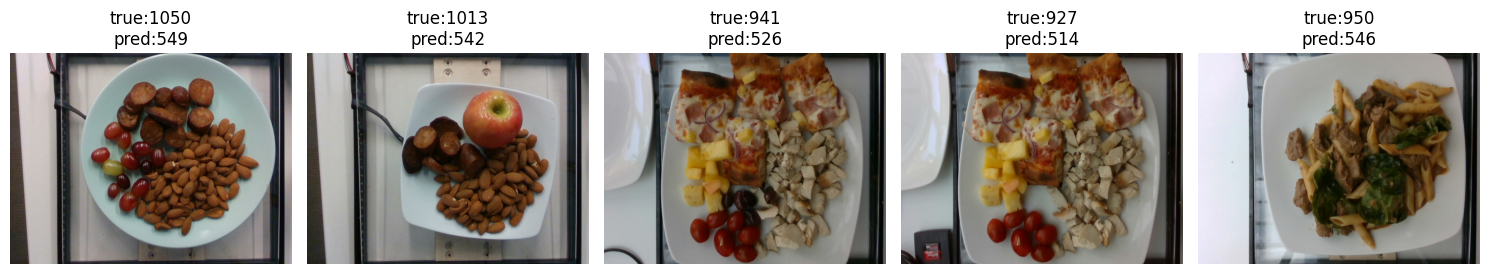

In [25]:
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(15,5))

for i, row in enumerate(top5.itertuples()):

    img_path = os.path.join(
        "data/images",
        str(row.dish_id),
        "rgb.png"
    )

    img = Image.open(img_path)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"true:{int(row.target)}\n"
        f"pred:{int(row.pred)}"
    )

plt.tight_layout()
plt.show()

---
# 5. Results

## Анализ пяти наиболее сложных примеров для модели

В рамках анализа ошибок были выбраны 5 блюд с наибольшим абсолютным отклонением предсказания от реального значения калорийности.

Общая закономерность заключается в том, что во всех примерах модель существенно занижает калорийность (на 400–500 ккал). Это говорит о том, что модель хорошо распознаёт базовый тип блюда, но недооценивает вклад высококалорийных ингредиентов.

## 1–2. Блюда с орехами и колбасой

INGREDIENTS:
almonds sausage grapes
sausage almonds

На изображениях присутствуют орехи и колбаса — продукты с высокой калорийностью.

Вероятные причины ошибки:

- орехи визуально воспринимаются моделью как небольшой объём пищи,
  однако они имеют очень высокую плотность калорий;
- модель ориентируется на визуальный объём, а не энергетическую ценность;
- текстовая модальность недостаточно компенсирует этот эффект.

В результате предсказание оказалось почти в два раза ниже реального значения.

## 3–4. Блюда с пиццей и курицей

INGREDIENTS:
pizza chicken pineapple tomatoes olives

Оба примера содержат пиццу — высококалорийный продукт,
но модель предсказывает значения около 500 ккал вместо ~930 ккал.

Возможные причины:

- пицца занимает лишь часть тарелки, и визуально блюдо кажется «лёгким»;
- наличие овощей и ананаса может смещать предсказание в сторону более низкой калорийности;
- модель плохо оценивает калорийность сложных составных блюд.

## 5. Паста с соусом и мясом

INGREDIENTS:
cream, olive oil, pasta, beef, sour cream, wine, mushrooms

Данное блюдо содержит множество скрытых калорийных ингредиентов:
сливки, масло, сметана, мясо.

Возможные причины ошибки:

- соусы и жирные компоненты плохо различимы на фотографии;
- визуально блюдо выглядит как обычная паста;
- модель недооценивает влияние сливочных и масляных ингредиентов,
  так как они не меняют форму блюда.

## Общий вывод

Основная причина ошибок — сложность оценки калорийности по визуальной информации.

Модель хорошо определяет тип блюда, однако испытывает трудности в следующих случаях:

- продукты с высокой энергетической плотностью (орехи, масло);
- скрытые калорийные ингредиенты (соусы, сливки);
- блюда с комбинированным составом;
- ситуации, когда реальная калорийность не соответствует визуальному объёму.

Это подтверждает, что для задачи предсказания калорийности критически важна текстовая информация о составе, однако текущая архитектура пока недостаточно эффективно учитывает её влияние.

## Гипотезы

- Основной гипотезой по улучшению качества метрик является расширение набора признаков. Ключевым признаком выделю энергетическую плотность продукта
- Также возникла идея добавить дополнительную модальность, а именно сегментацию продуктов на изображении. Идея заключается в том, чтобы в процентном соотношении высчитывать состав каждого ингредиента от общей площади блюда, это позволит выделить признак относительного объёма продукта и возможно повысить точность оценки каллорийности

На этом пока всё. Благодарю за внимание и спасибо Yandex Practicum за проект! 15.02.2026 23:09.

---